In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import xarray as xr
import numpy as np
import sys
from pathlib import Path
from thermofeel import thermofeel
import geopandas as gpd
import xarray as xr
import rioxarray
from rasterio.enums import Resampling

In [2]:
def calculate_relative_humidity_percent(t2_k, td_k):
    t2_c = kelvin_to_celsius(t2_k)
    td_c = kelvin_to_celsius(td_k)
    # saturated vapour pressure
    es = 6.11 * 10.0 ** (7.5 * t2_c / (237.3 + t2_c))
    # vapour pressure
    e = 6.11 * 10.0 ** (7.5 * td_c / (237.3 + td_c))
    rh = (e / es) * 100
    return rh

def calculate_saturation_vapour_pressure(t2_k):
    g = [
        -2.8365744e3,
        -6.028076559e3,
        1.954263612e1,
        -2.737830188e-2,
        1.6261698e-5,
        7.0229056e-10,
        -1.8680009e-13,
        2.7150305,
    ]
    ess = g[7] * np.log(t2_k)
    for i in range(7):
        ess = ess + g[i] * np.power(t2_k, (i - 2))
    ess = np.exp(ess) * 0.01  # hPa
    return ess

def kelvin_to_celsius(temp_k):
    """Convert Kelvin to Celsius preserving xarray metadata"""
    return temp_k - 273.15

def celsius_to_kelvin(temp_c):

    """Convert Celsius to Kelvin preserving xarray metadata"""
    return temp_c + 273.15

In [3]:
variables = [ 'UTCI', 'tas', 'MRT', 'wvp', 'ws']
path = '../create_analysis_dataset/data/'
path = 'data/'
var = 'UTCI'  # Can be changed to 'UTCI' or other heat indices
baseline_time = slice('1970', '1999')
recent_time = slice('1993', '2022')

In [4]:
# Location coordinates
locations = {
    'cpt': (-33.8, 18.6),
    'jhb': (-26.1, 28.0),
    'abj': (5.45, -3.9),
    'lua': (-8.994111, 13.439933)
}

names = {'cpt': 'Cape Town', 'jhb': 'Johannesburg', 'abj': 'Abidjan', 'lua': 'Luanda'}

In [5]:
ds = xr.open_zarr(f'{path}/heat_analysis_set.zarr')

ds['rh'] = calculate_relative_humidity_percent(ds.tas, ds.tasdp)
ds['wvp'] = (calculate_saturation_vapour_pressure(ds.tas) * ds.rh / 100.0) / 10.0  # water vapour pressure in kPa

ds = ds.sel(latitude = slice(20,-60))[variables]

baseline = ds.sel(time = baseline_time).chunk({"time": -1})
recent = ds.sel(time = recent_time).chunk({"time": -1})

In [6]:
gdf = gpd.read_file("data/regions.geojson")

In [7]:

ds = ds.rio.write_crs("EPSG:4326")

regions = {}
for label in gdf['label']:
    selected_region = gdf[gdf['label'] == label]
    regions[label] = ds.rio.clip(selected_region.geometry.values, selected_region.crs, drop=True)

In [8]:
regions_recent = {}
regions_baseline = {}
thresholds_recent = {}
thresholds_baseline = {}

for label in gdf['label']:

    regions_recent[label] = regions[label].sel(time=recent_time)
    regions_baseline[label] = regions[label].sel(time=baseline_time)

    thresholds_recent[label] = regions_recent[label].UTCI.quantile(0.99, dim='time').compute()
    thresholds_baseline[label] = regions_baseline[label].UTCI.quantile(0.99, dim='time').compute()

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


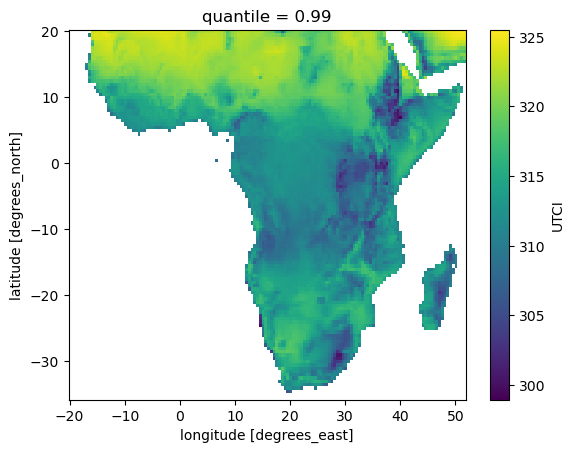

In [9]:
ds.sel(time = baseline_time).UTCI.quantile(0.99, dim = 'time').plot()

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().we

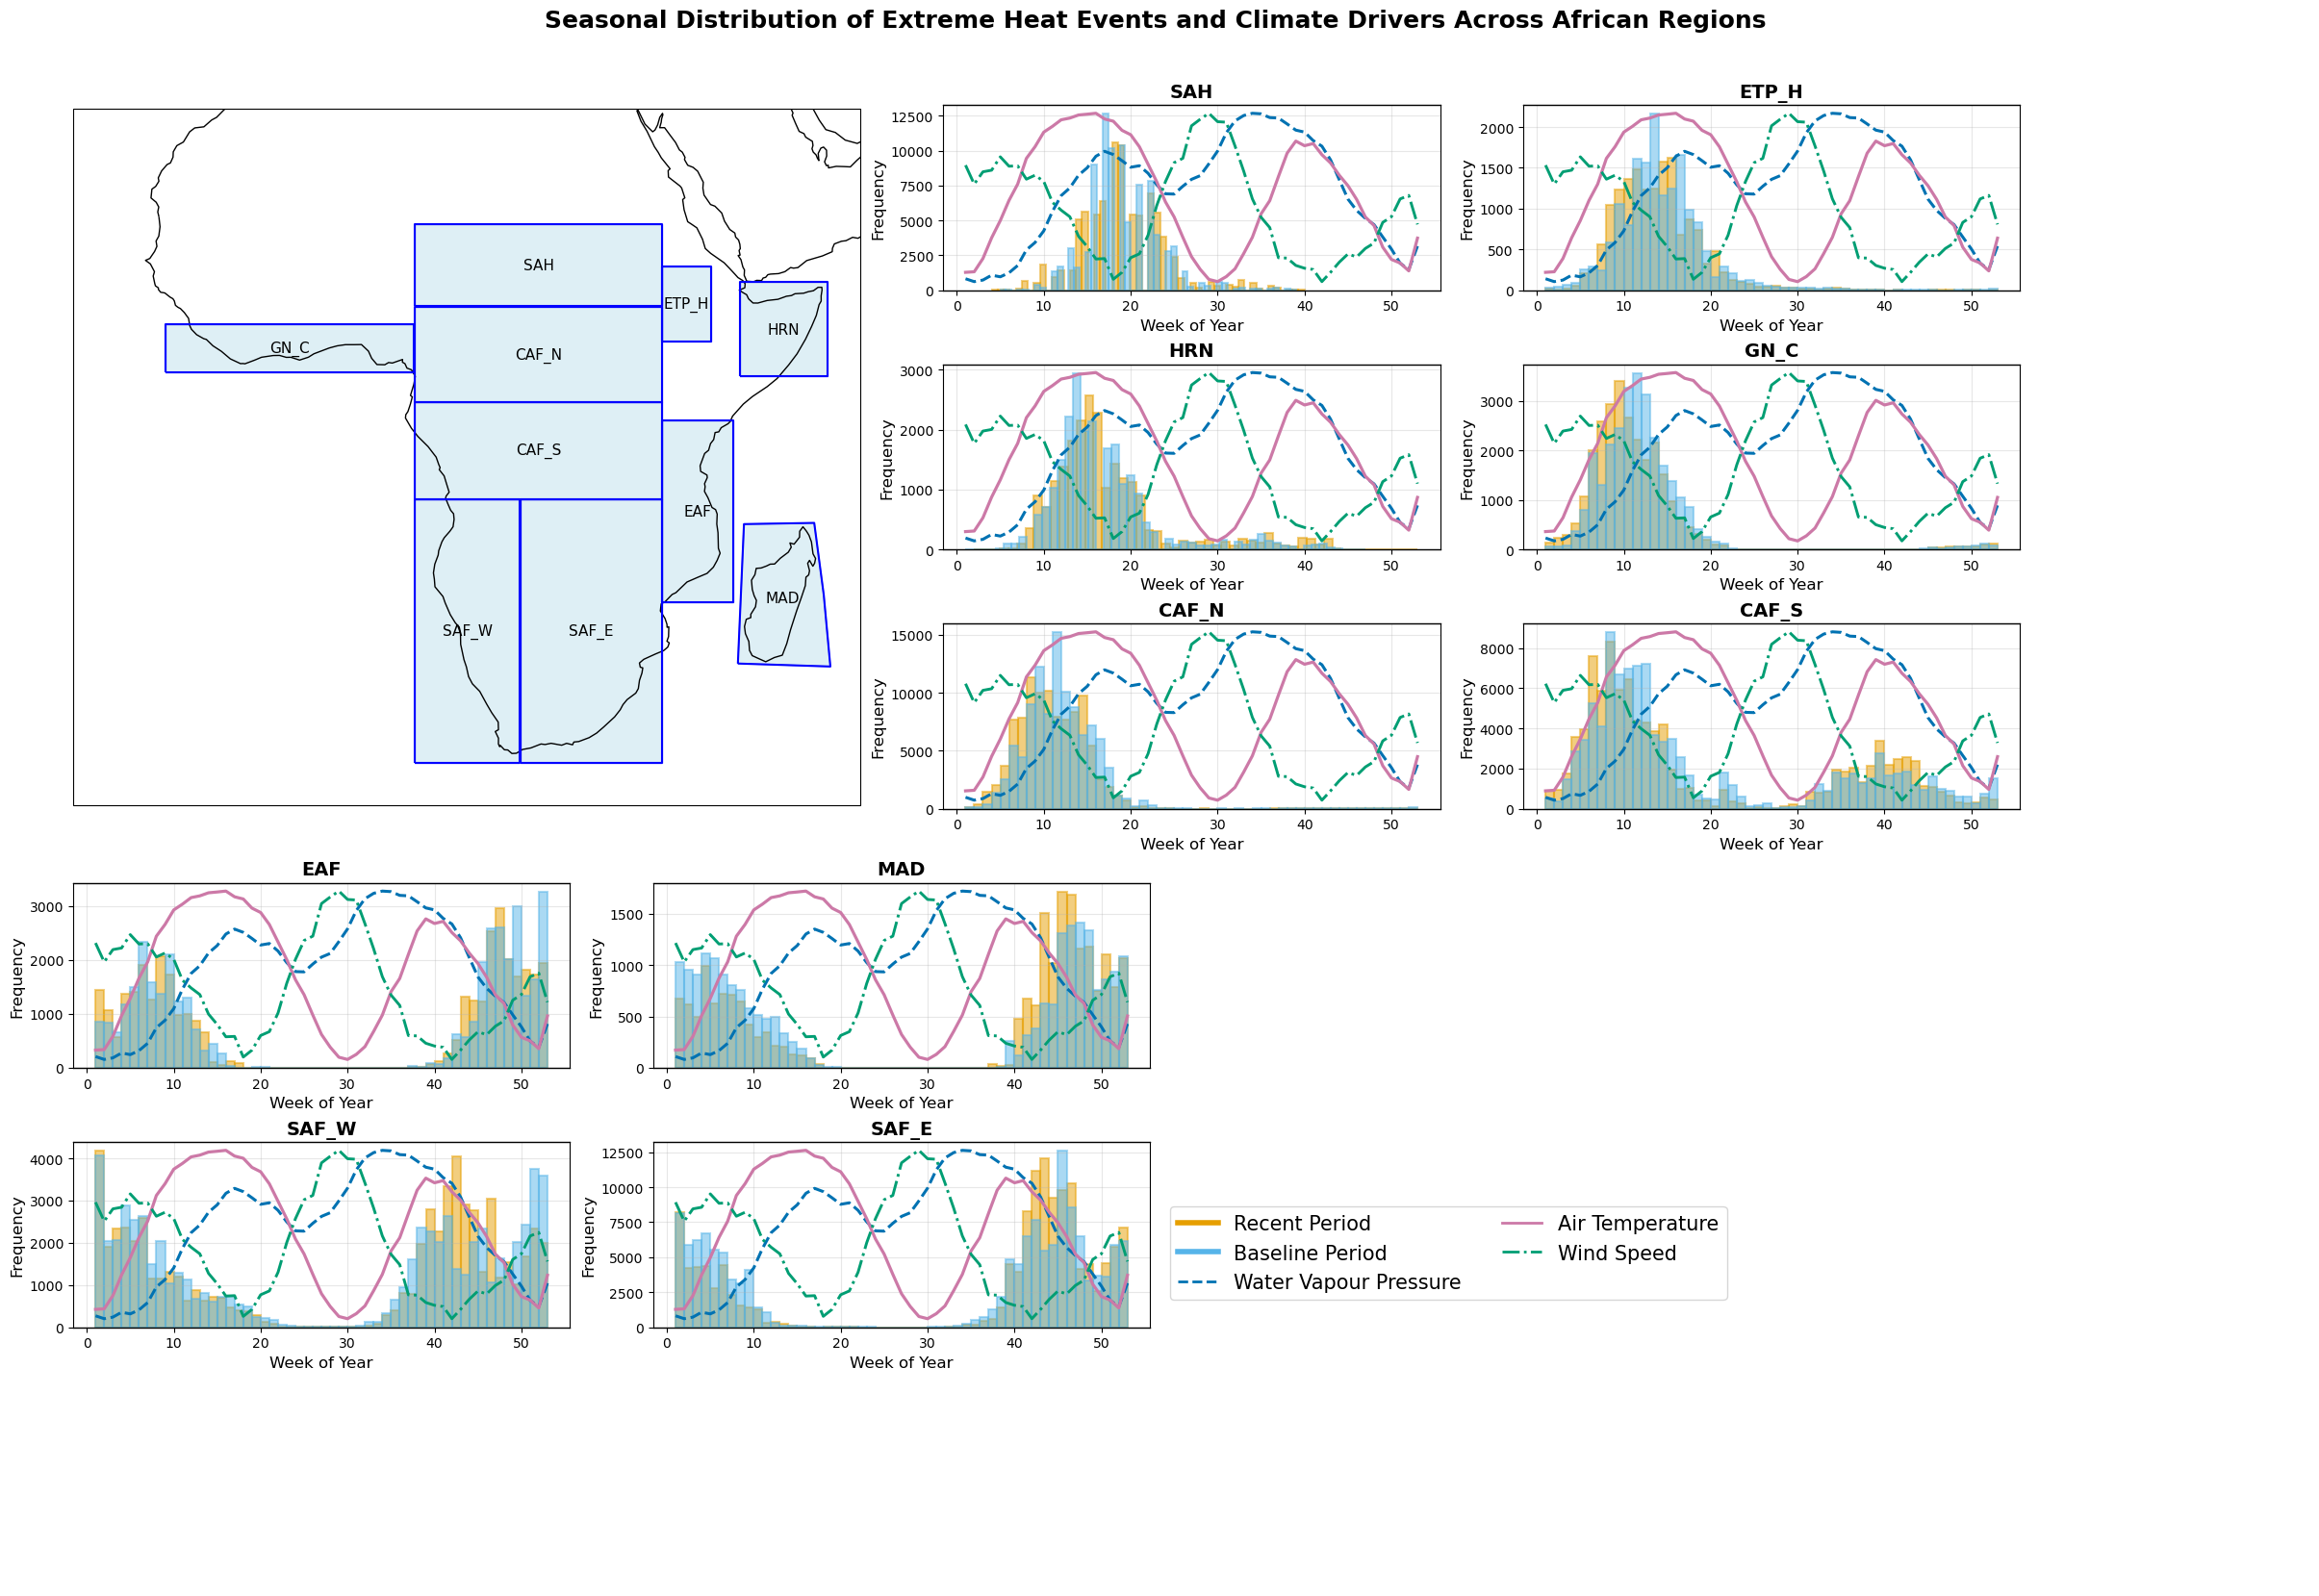

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import xarray as xr
import numpy as np

colors = {
    "recent": "#E69F00",   # orange
    "baseline": "#56B4E9", # blue
    "ws": "#009E73",       # bluish green
    "wvp": "#0072B2",      # dark blue
    "tas": "#CC79A7",      # magenta
}

region_names = ['SAH', 'ETP_H', 'HRN', 'GN_C', 'CAF_N', 'CAF_S', 'EAF', 'MAD', 'SAF_W', 'SAF_E']

# Create figure with wider layout to accommodate double-width histograms
fig = plt.figure(figsize=(30, 20))
gs = fig.add_gridspec(6, 8, hspace=0.4, wspace=0.4)

# Map in top left (spans 3x3 for better proportion)
map_ax = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
map_ax.set_extent([-25, 55, -40, 30], crs=ccrs.PlateCarree())
map_ax.coastlines()

#thresh = ds.sel(time=baseline_time).UTCI.quantile(0.99, dim='time').plot(ax=map_ax, add_colorbar=False)

gdf = gpd.read_file("data/regions.geojson")
gdf.boundary.plot(ax=map_ax, edgecolor='blue')
gdf.plot(ax=map_ax, alpha=0.4, facecolor='lightblue', edgecolor='blue')

for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    label = row.label
    map_ax.text(centroid.x, centroid.y, label, transform=ccrs.PlateCarree(),
                ha='center', va='center', fontsize=11)

# --- Create 10 histogram axes (each spanning 2 columns for double width)
axes = []

# Row 1: 2 histograms to the right of map (each 2 columns wide)
axes.append(fig.add_subplot(gs[0, 3:5]))  # First histogram
axes.append(fig.add_subplot(gs[0, 5:7]))  # Second histogram

# Row 2: 2 more histograms to the right of map
axes.append(fig.add_subplot(gs[1, 3:5]))  # Third histogram  
axes.append(fig.add_subplot(gs[1, 5:7]))  # Fourth histogram

# Row 3: 2 more histograms to the right of map
axes.append(fig.add_subplot(gs[2, 3:5]))  # Fifth histogram
axes.append(fig.add_subplot(gs[2, 5:7]))  # Sixth histogram

# Row 4: 2 histograms (full width)
axes.append(fig.add_subplot(gs[3, 0:2]))  # Seventh histogram
axes.append(fig.add_subplot(gs[3, 2:4]))  # Eighth histogram

# Row 5: 2 final histograms
axes.append(fig.add_subplot(gs[4, 0:2]))  # Ninth histogram
axes.append(fig.add_subplot(gs[4, 2:4]))  # Tenth histogram

# --- Plot histograms
for idx, region in enumerate(region_names):
    ax1 = axes[idx]

    recent = regions_recent[region]
    baseline = regions_baseline[region]

    recent_threshold = thresholds_recent[region]
    baseline_threshold = thresholds_baseline[region]

    # Week of year
    woy_recent = recent.time.dt.isocalendar().week
    woy_broadcasted_recent = xr.ones_like(recent['UTCI']) * woy_recent.values[:, np.newaxis, np.newaxis]
    recent = recent.assign(woy=xr.DataArray(woy_broadcasted_recent, dims=("time", "latitude", "longitude"), coords=recent['UTCI'].coords))

    woy_baseline = baseline.time.dt.isocalendar().week
    woy_broadcasted_baseline = xr.ones_like(baseline['UTCI']) * woy_baseline.values[:, np.newaxis, np.newaxis]
    baseline = baseline.assign(woy=xr.DataArray(woy_broadcasted_baseline, dims=("time", "latitude", "longitude"), coords=baseline['UTCI'].coords))

    # Filter for extremes
    recent_extreme = recent.where(recent.UTCI > recent_threshold).stack(space=['time', 'latitude', 'longitude']).dropna(dim='space') # mod here for baseline or recent thresh
    baseline_extreme = baseline.where(baseline.UTCI > baseline_threshold).stack(space=['time', 'latitude', 'longitude']).dropna(dim='space')

    ax1.hist(recent_extreme.woy.values, bins=52,
             edgecolor=colors["recent"], facecolor=colors["recent"],
             alpha=0.5, linewidth=1.5, label='Recent')
    ax1.hist(baseline_extreme.woy.values, bins=52,
             edgecolor=colors["baseline"], facecolor=colors["baseline"],
             alpha=0.5, linewidth=1.5, label='Baseline')

    ax1.set_title(f'{region}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Week of Year', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.tick_params(labelsize=10)
    ax1.grid(True, alpha=0.3)

    # Overlay climatology
    lat = ds.latitude
    weights = np.cos(np.deg2rad(lat))
    weights /= weights.mean()
    clim = (
        ds
        .weighted(weights)
        .mean(dim=['latitude', 'longitude'])
        .groupby('time.weekofyear')
        .mean(dim='time')
    )

    for i, (var, col, lw, ls) in enumerate([
        ("wvp", colors["wvp"], 2.2, '--'),      
        ("tas", colors["tas"], 2.3, '-'),    
        ("ws", colors["ws"], 2.1, '-.'), 
    ]):
        ax = ax1.twinx()
        ax.spines.right.set_position(("axes", 1.1 + i * 0.12))
        ax.plot(clim.weekofyear, getattr(clim, var), color=col, linewidth=lw, linestyle=ls)
        ax.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

# --- Legend positioned in the remaining space
legend_handles = [
    plt.Line2D([0], [0], color=colors["recent"], lw=4, label='Recent Period'),
    plt.Line2D([0], [0], color=colors["baseline"], lw=4, label='Baseline Period'),
    plt.Line2D([0], [0], color=colors["wvp"], lw=2, linestyle='--', label='Water Vapour Pressure'),
    plt.Line2D([0], [0], color=colors["tas"], lw=2, linestyle='-', label='Air Temperature'),
    plt.Line2D([0], [0], color=colors["ws"], lw=2, linestyle='-.', label='Wind Speed'),
]

# Create legend in the bottom right area
legend_ax = fig.add_subplot(gs[4:6, 4:8])
legend_ax.axis('off')
legend_ax.legend(handles=legend_handles, loc='center', ncol=2, 
                fontsize=15, bbox_to_anchor=(0.2, 0.75))

# --- Add colorbar for the "thresh" plot below the legend
# Assumes you have a QuadMesh or similar object from plt.pcolormesh or plt.imshow called "thresh"
# and that you want to add its colorbar below the legend

fig.suptitle('Seasonal Distribution of Extreme Heat Events and Climate Drivers Across African Regions', 
             fontsize=18, fontweight='bold', y=0.93)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plots/06_seasonality_dynamic_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
da = xr.open_zarr(f'{path}/heat_analysis_set.zarr')[var] - 273.15
da = da.sel(latitude = slice(20,-60))

baseline = da.sel(time = baseline_time)
recent = da.sel(time = recent_time)

threshold_90 = baseline.chunk({'time': -1}).quantile(0.99, dim='time').compute()
valid_mask = ~np.isnan(threshold_90)

<xarray.Dataset> Size: 6GB
Dimensions:      (time: 19357, latitude: 112, longitude: 144)
Coordinates:
  * latitude     (latitude) float32 448B 19.9 19.4 18.9 ... -34.6 -35.1 -35.6
  * longitude    (longitude) float32 576B -19.9 -19.4 -18.9 ... 50.6 51.1 51.6
  * time         (time) datetime64[ns] 155kB 1970-01-01T11:30:00 ... 2022-12-...
    spatial_ref  int64 8B 0
Data variables:
    UTCI         (time, latitude, longitude) float32 1GB dask.array<chunksize=(250, 1, 36), meta=np.ndarray>
    tas          (time, latitude, longitude) float32 1GB dask.array<chunksize=(250, 1, 36), meta=np.ndarray>
    MRT          (time, latitude, longitude) float32 1GB dask.array<chunksize=(250, 1, 36), meta=np.ndarray>
    wvp          (time, latitude, longitude) float32 1GB dask.array<chunksize=(250, 1, 36), meta=np.ndarray>
    ws           (time, latitude, longitude) float32 1GB dask.array<chunksize=(250, 1, 36), meta=np.ndarray>

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().we

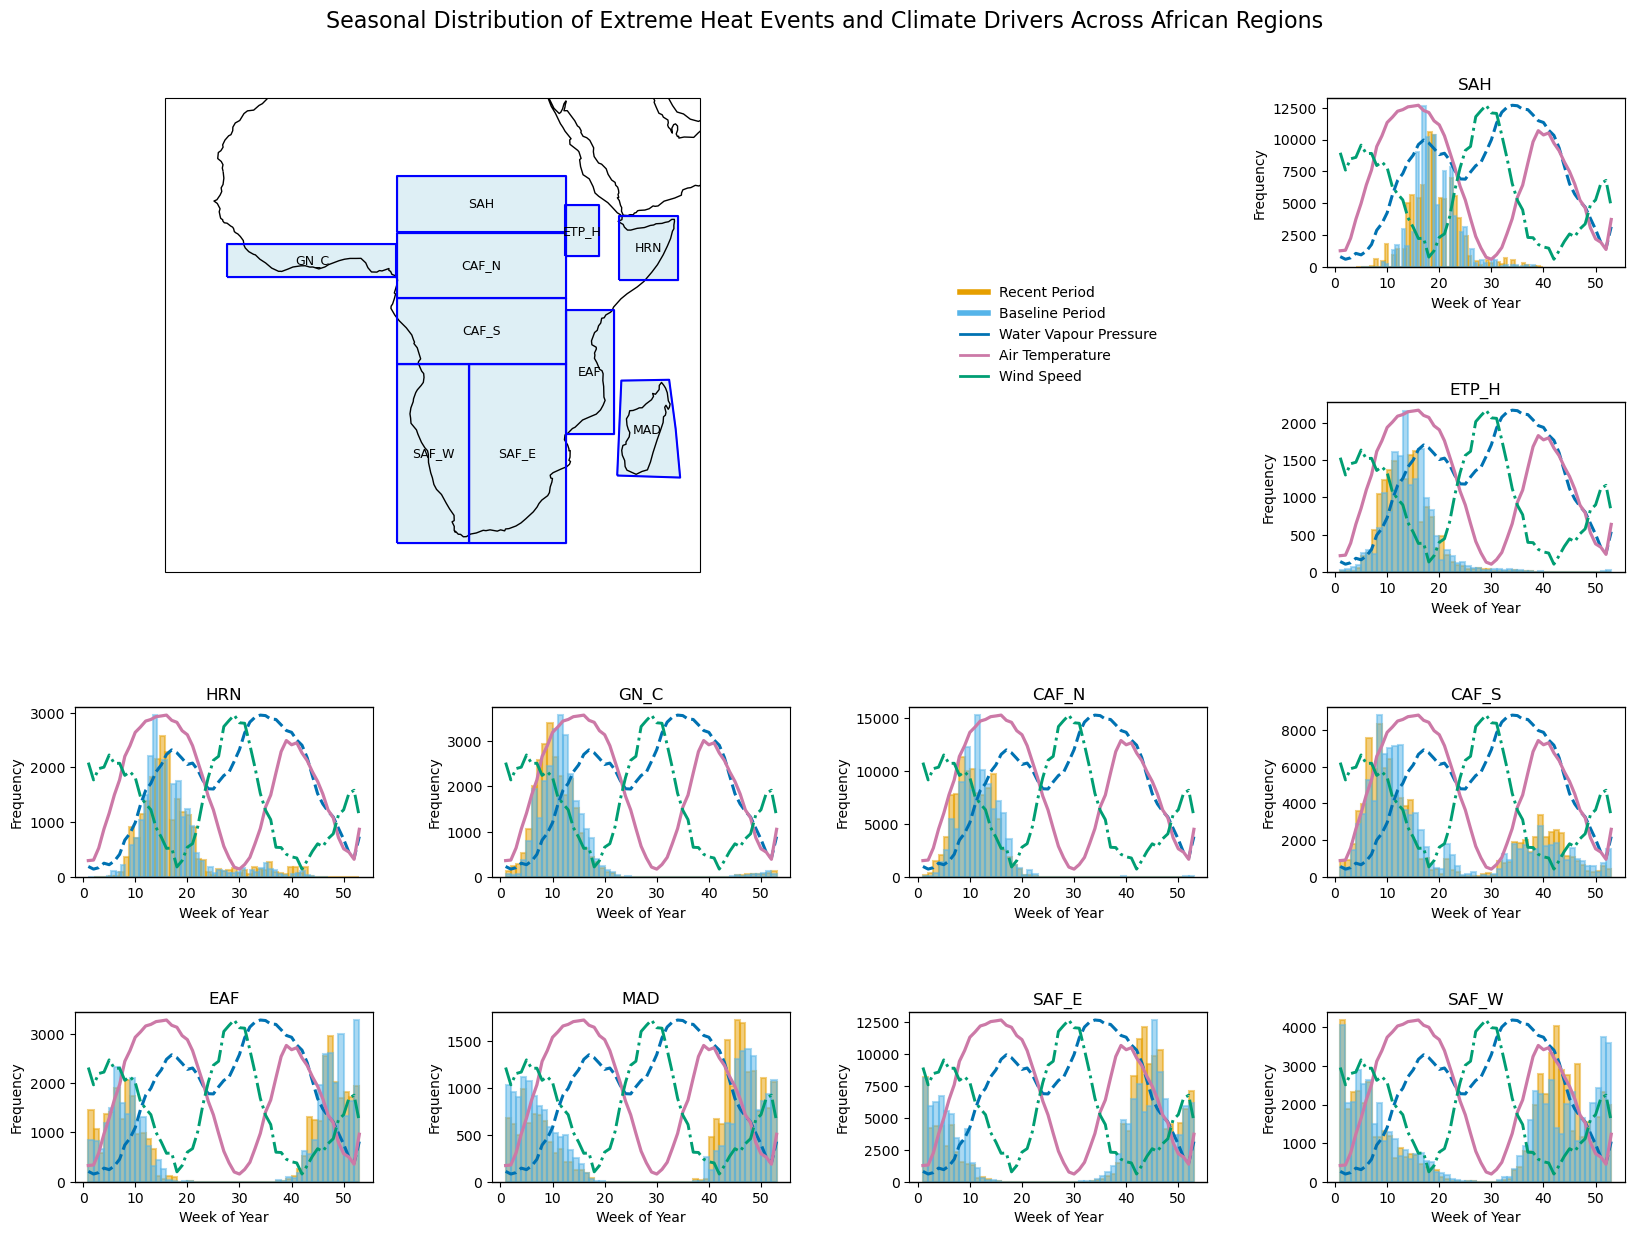

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import xarray as xr
import numpy as np

colors = {
    "recent": "#E69F00",   # orange
    "baseline": "#56B4E9", # blue
    "ws": "#009E73",       # bluish green
    "wvp": "#0072B2",      # dark blue
    "tas": "#CC79A7",      # same as wvp
    #"MRT": "#D55E00",      # vermillion
    #"UTCI": "#CC79A7",     # purple
}

region_names = ['SAH', 'ETP_H', 'HRN', 'GN_C', 'CAF_N', 'CAF_S', 'EAF', 'MAD', 'SAF_E', 'SAF_W']

fig = plt.figure(figsize=(20, 22))
gs = fig.add_gridspec(6, 4, hspace=0.8, wspace=0.4)

# Reference map (now 2x2)
map_ax = fig.add_subplot(gs[0:2, 0:2], projection=ccrs.PlateCarree())
map_ax.set_extent([-25, 55, -40, 30], crs=ccrs.PlateCarree())
map_ax.coastlines()

gdf = gpd.read_file("data/regions.geojson")
gdf.boundary.plot(ax=map_ax, edgecolor='blue')
gdf.plot(ax=map_ax, alpha=0.4, facecolor='lightblue', edgecolor='blue')

for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    label = row.label
    map_ax.text(centroid.x, centroid.y, label, transform=ccrs.PlateCarree(),
                ha='center', va='center', fontsize=9)

# Legend panel (moved to right of map)
legend_ax = fig.add_subplot(gs[0:2, 2])
legend_ax.axis('off')
legend_handles = [
    plt.Line2D([0], [0], color=colors["recent"], lw=4, label='Recent Period'),
    plt.Line2D([0], [0], color=colors["baseline"], lw=4, label='Baseline Period'),
    plt.Line2D([0], [0], color=colors["wvp"], lw=2, label='Water Vapour Pressure'),
    plt.Line2D([0], [0], color=colors["tas"], lw=2, label='Air Temperature'),
    plt.Line2D([0], [0], color=colors["ws"], lw=2, label='Wind Speed'),
]
legend_ax.legend(handles=legend_handles, loc='center', frameon=False, fontsize=10)

# Histogram axes - rearranged around the map
axes = []
positions = [
    (0, 3), (1, 3),  # Right of map
    (2, 0), (2, 1), (2, 2), (2, 3),  # Below map
    (3, 0), (3, 1), (3, 2), (3, 3),  # Bottom row
]
for row, col in positions:
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

# Rest of the code remains the same for plotting histograms
for idx, region in enumerate(region_names):
    ax1 = axes[idx]

    recent = regions_recent[region]
    baseline = regions_baseline[region]

    recent_threshold = thresholds_recent[region]
    baseline_threshold = thresholds_baseline[region]

    # For recent period
    woy_recent = recent.time.dt.isocalendar().week
    woy_broadcasted_recent = xr.ones_like(recent['UTCI']) * woy_recent.values[:, np.newaxis, np.newaxis]
    woy_broadcasted_recent = xr.DataArray(
        woy_broadcasted_recent, 
        dims=("time", "latitude", "longitude"), 
        coords=recent['UTCI'].coords
    )
    recent = recent.assign(woy=woy_broadcasted_recent)

    # Find extremes and stack
    recent_extreme = recent.where(recent.UTCI > recent_threshold)
    recent_extreme = recent_extreme.stack(space=['time', 'latitude', 'longitude'])
    recent_extreme = recent_extreme.dropna(dim='space')

    # For baseline period
    woy_baseline = baseline.time.dt.isocalendar().week
    woy_broadcasted_baseline = xr.ones_like(baseline['UTCI']) * woy_baseline.values[:, np.newaxis, np.newaxis]
    woy_broadcasted_baseline = xr.DataArray(
        woy_broadcasted_baseline, 
        dims=("time", "latitude", "longitude"), 
        coords=baseline['UTCI'].coords
    )
    baseline = baseline.assign(woy=woy_broadcasted_baseline)

    # Find extremes and stack
    baseline_extreme = baseline.where(baseline.UTCI > baseline_threshold)
    baseline_extreme = baseline_extreme.stack(space=['time', 'latitude', 'longitude'])
    baseline_extreme = baseline_extreme.dropna(dim='space')

    ax1.hist(recent_extreme.woy.values, bins=52,
             edgecolor=colors["recent"], facecolor=colors["recent"],
             alpha=0.5, linewidth=1.5, label='Recent')
    ax1.hist(baseline_extreme.woy.values, bins=52,
             edgecolor=colors["baseline"], facecolor=colors["baseline"],
             alpha=0.5, linewidth=1.5, label='Baseline')

    ax1.set_title(f'{region}')
    ax1.set_xlabel('Week of Year')
    ax1.set_ylabel('Frequency')

    # Weighted climatology
    lat = ds.latitude
    weights = np.cos(np.deg2rad(lat))
    weights /= weights.mean()
    clim = (
        ds
        .weighted(weights)
        .mean(dim=['latitude', 'longitude'])
        .groupby('time.weekofyear')
        .mean(dim='time')
    )

    # Overlay time series
    #ax1.plot(clim.weekofyear, clim.ws, color=colors["ws"], linewidth=1.5)
    for i, (var, col, lw, ls) in enumerate([
        ("wvp", colors["wvp"], 2.2, '--'),      
        ("tas", colors["tas"], 2.3, '-'),    
        ("ws", colors["ws"], 2.1, '-.'), 
    ]):
        ax = ax1.twinx()
        ax.spines.right.set_position(("axes", 1.1 + i * 0.1))
        ax.plot(clim.weekofyear, getattr(clim, var), color=col, linewidth=lw, linestyle=ls)
        ax.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('Seasonal Distribution of Extreme Heat Events and Climate Drivers Across African Regions', fontsize=16, y=0.92)

plt.tight_layout()
plt.savefig('plots/06_seasonality.png', dpi=300)
plt.show()

In [22]:
label = gdf['label'].iloc[0]

regions_recent[label] = regions[label].sel(time=recent_time)
regions_baseline[label] = regions[label].sel(time=baseline_time)

thresholds_recent[label] = regions_recent[label].quantile(0.99, dim='time').UTCI
thresholds_baseline[label] = regions_baseline[label].quantile(0.99, dim='time').UTCI

recent = regions_recent[label]
baseline = regions_baseline[label]

recent_threshold = thresholds_recent[label]
baseline_threshold = thresholds_baseline[label]

# WOY
woy_recent = recent.time.dt.isocalendar().week
woy_broadcasted_recent = xr.ones_like(recent['UTCI']) * woy_recent.values[:, np.newaxis, np.newaxis]
recent = recent.assign(woy=xr.DataArray(
    woy_broadcasted_recent, dims=("time", "latitude", "longitude"), coords=recent['UTCI'].coords
))

# Extremes
recent_extreme = recent.where(recent.UTCI > recent_threshold).UTCI.stack(space=['time', 'latitude', 'longitude']).dropna(dim='space')


In [23]:
recent_extreme

<xarray.DataArray 'UTCI' (space: 15900)> Size: 64kB
dask.array<getitem, shape=(15900,), dtype=float32, chunksize=(15900,), chunktype=numpy.ndarray>
Coordinates:
    spatial_ref  int64 8B 0
    quantile     float64 8B 0.99
  * space        (space) object 127kB MultiIndex
  * time         (space) datetime64[ns] 127kB 1993-03-06T11:30:00 ... 2022-09...
  * latitude     (space) float32 64kB 10.9 9.9 8.4 7.9 ... 12.4 12.4 11.9 7.9
  * longitude    (space) float32 64kB 39.6 39.1 39.6 38.6 ... 39.6 39.6 39.6
Attributes:
    code:         167
    institution:  ECMWF
    table:        128

In [19]:
baseline_extreme

<xarray.Dataset> Size: 16B
Dimensions:      (space: 0)
Coordinates:
    spatial_ref  int64 8B 0
    quantile     float64 8B 0.99
  * space        (space) object 0B MultiIndex
  * time         (space) datetime64[ns] 0B 
  * latitude     (space) float32 0B 
  * longitude    (space) float32 0B 
Data variables:
    UTCI         (space) float32 0B dask.array<chunksize=(0,), meta=np.ndarray>
    tas          (space) float32 0B dask.array<chunksize=(0,), meta=np.ndarray>
    MRT          (space) float32 0B dask.array<chunksize=(0,), meta=np.ndarray>
    wvp          (space) float32 0B dask.array<chunksize=(0,), meta=np.ndarray>
    ws           (space) float32 0B dask.array<chunksize=(0,), meta=np.ndarray>

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data


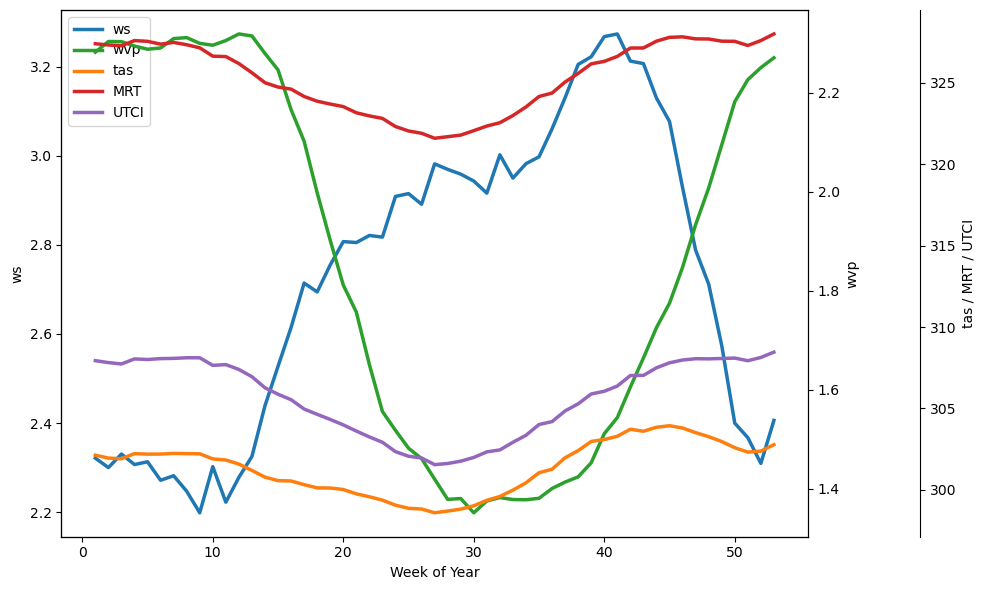

In [ ]:


# Calculate area weights for the region
lat = regions['EAF'].latitude
weights = np.cos(np.deg2rad(lat))
weights = weights / weights.mean()  # Normalize weights for numerical stability

# Calculate the weekly mean climatology (area-weighted mean of each week of year)
weekly_climatology = (
    regions['EAF']
    .weighted(weights)
    .mean(dim=['latitude', 'longitude'])
    .groupby('time.weekofyear')
    .mean(dim='time')
)
fig, ax1 = plt.subplots(figsize=(10,6))

lines = []
labels = []

# First variable (ws)
l1, = ax1.plot(
    weekly_climatology.weekofyear, weekly_climatology.ws, 
    color='tab:blue', label='ws', linewidth=2.5
)
ax1.set_ylabel('ws')
lines.append(l1)
labels.append('ws')

# Second axis for wvp
ax2 = ax1.twinx()
l2, = ax2.plot(
    weekly_climatology.weekofyear, weekly_climatology.wvp, 
    color='tab:green', label='wvp', linewidth=2.5
)
ax2.set_ylabel('wvp')
lines.append(l2)
labels.append('wvp')

# Third axis for tas, MRT, UTCI (share the same axis)
ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.15))

l3, = ax3.plot(
    weekly_climatology.weekofyear, weekly_climatology.tas, 
    color='tab:orange', label='tas', linewidth=2.5
)
l4, = ax3.plot(
    weekly_climatology.weekofyear, weekly_climatology.MRT, 
    color='tab:red', label='MRT', linewidth=2.5
)
l5, = ax3.plot(
    weekly_climatology.weekofyear, weekly_climatology.UTCI, 
    color='tab:purple', label='UTCI', linewidth=2.5
)
ax3.set_ylabel('tas / MRT / UTCI')
lines.extend([l3, l4, l5])
labels.extend(['tas', 'MRT', 'UTCI'])

# Combine all lines for a single legend
ax1.legend(lines, labels, loc='upper left')
ax1.set_xlabel('Week of Year')
plt.tight_layout()
plt.show()

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().we

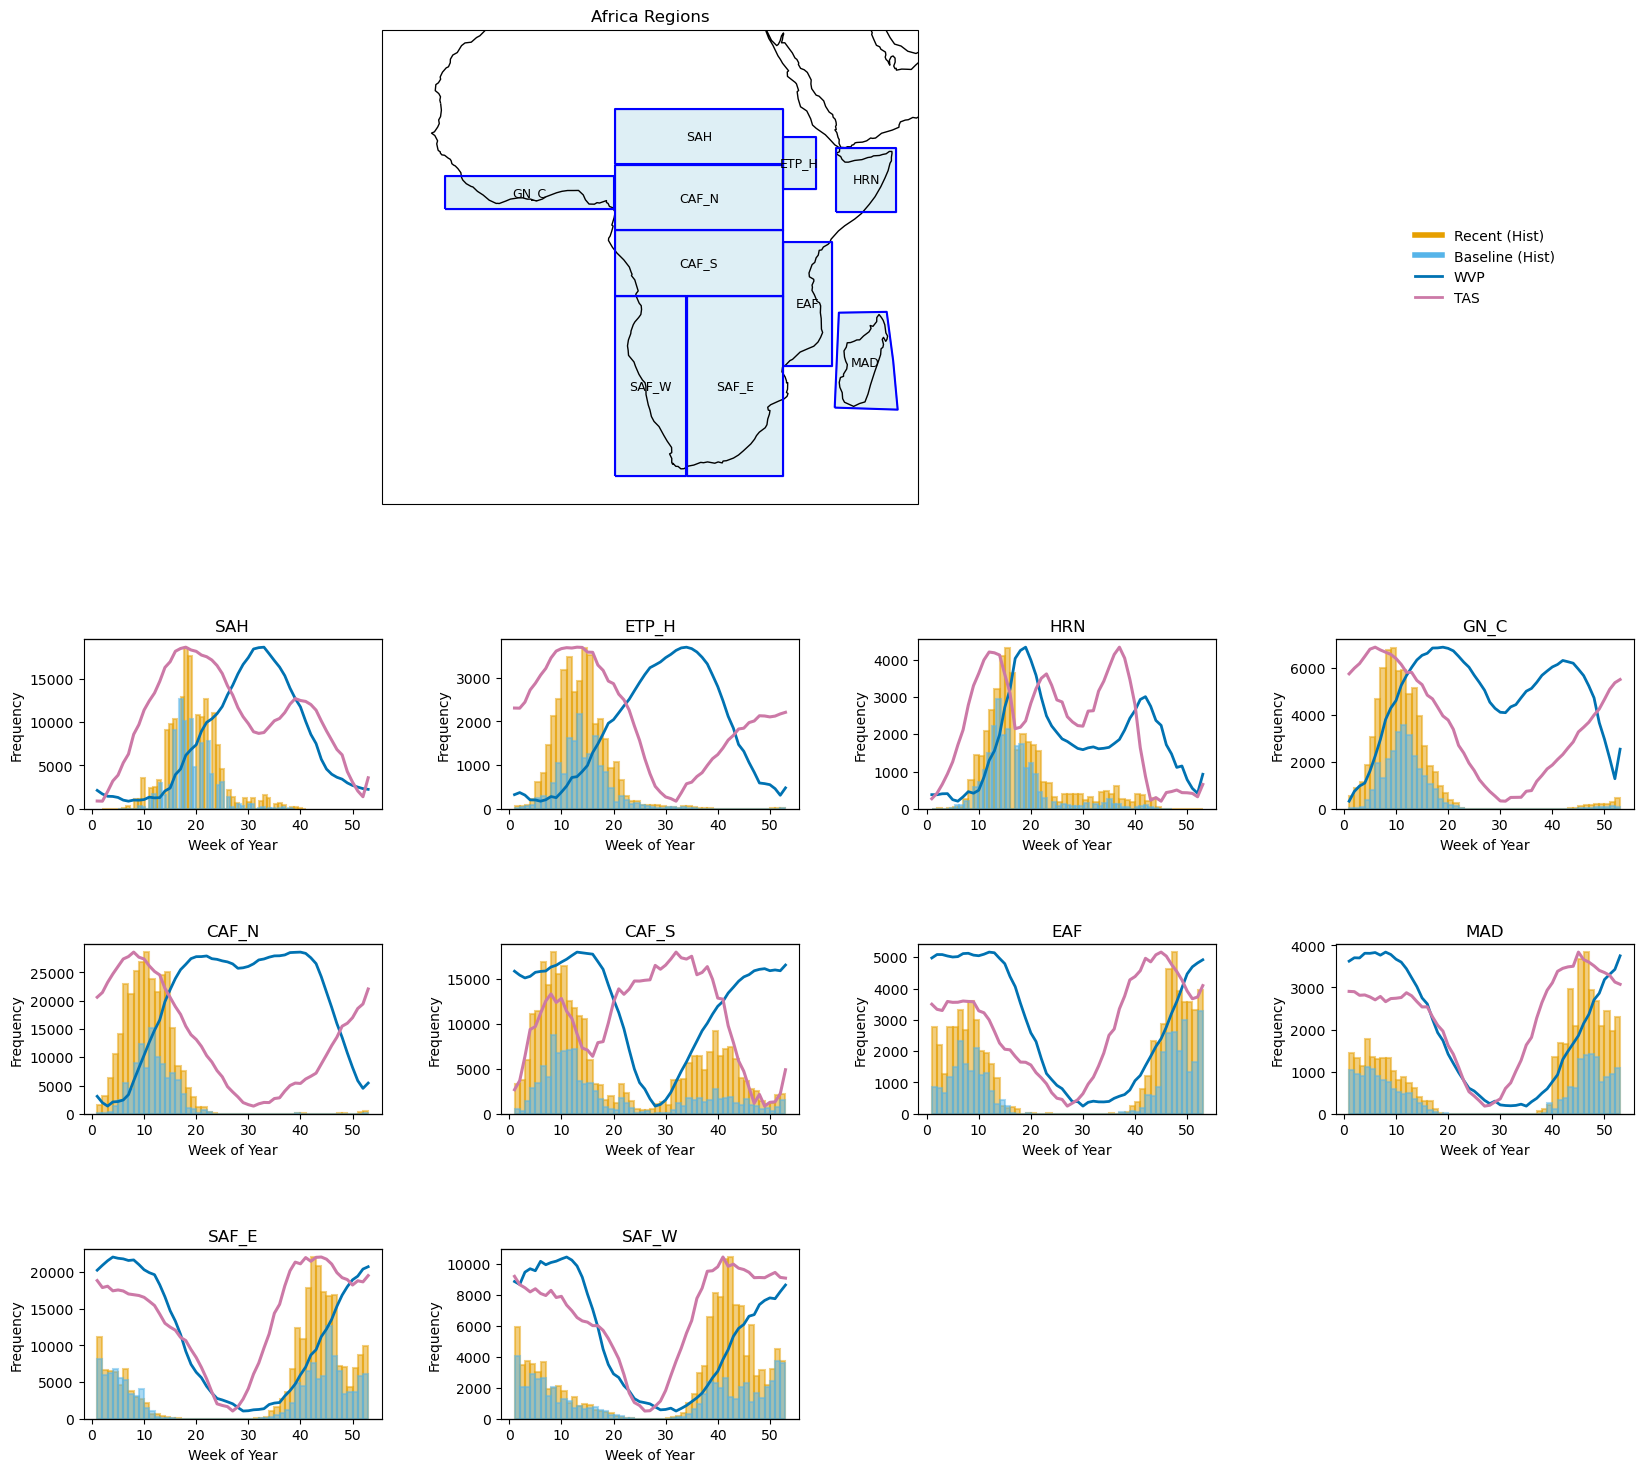

In [128]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import xarray as xr
import numpy as np

colors = {
    "recent": "#E69F00",   # orange
    "baseline": "#56B4E9", # blue
    #"ws": "#009E73",       # bluish green
    "wvp": "#0072B2",      # dark blue
    "tas": "#CC79A7",      # same as wvp
    #"MRT": "#D55E00",      # vermillion
    #"UTCI": "#CC79A7",     # purple
}

region_names = ['SAH', 'ETP_H', 'HRN', 'GN_C', 'CAF_N', 'CAF_S', 'EAF', 'MAD', 'SAF_E', 'SAF_W']

fig = plt.figure(figsize=(20, 22))
gs = fig.add_gridspec(6, 4, hspace=0.8, wspace=0.4)

# Reference map (larger)
map_ax = fig.add_subplot(gs[0:2, 0:3], projection=ccrs.PlateCarree())
map_ax.set_extent([-25, 55, -40, 30], crs=ccrs.PlateCarree())
map_ax.coastlines()
map_ax.set_title("Africa Regions")

gdf = gpd.read_file("data/regions.geojson")
gdf.boundary.plot(ax=map_ax, edgecolor='blue')
gdf.plot(ax=map_ax, alpha=0.4, facecolor='lightblue', edgecolor='blue')

for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    label = row.label
    map_ax.text(centroid.x, centroid.y, label, transform=ccrs.PlateCarree(),
                ha='center', va='center', fontsize=9)

# Legend panel
legend_ax = fig.add_subplot(gs[0:2, 3])
legend_ax.axis('off')
legend_handles = [
    plt.Line2D([0], [0], color=colors["recent"], lw=4, label='Recent (Hist)'),
    plt.Line2D([0], [0], color=colors["baseline"], lw=4, label='Baseline (Hist)'),
    #plt.Line2D([0], [0], color=colors["ws"], lw=2, label='WS'),
    plt.Line2D([0], [0], color=colors["wvp"], lw=2, label='WVP'),
    plt.Line2D([0], [0], color=colors["tas"], lw=2, label='TAS'),
    #plt.Line2D([0], [0], color=colors["MRT"], lw=2, label='MRT'),
]
legend_ax.legend(handles=legend_handles, loc='center', frameon=False, fontsize=10)

# Histogram axes
axes = []
positions = [
    (2, 0), (2, 1), (2, 2), (2, 3),
    (3, 0), (3, 1), (3, 2), (3, 3),
    (4, 0), (4, 1)
]
for row, col in positions:
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

# Plot histograms
for idx, region in enumerate(region_names):
    ax1 = axes[idx]

    ds = regions[region]
    woy = ds.time.dt.isocalendar().week
    woy_broadcasted = xr.ones_like(ds['UTCI']) * woy.values[:, np.newaxis, np.newaxis]
    woy_broadcasted = xr.DataArray(woy_broadcasted, dims=("time", "latitude", "longitude"), coords=ds['UTCI'].coords)
    ds = ds.assign(woy=woy_broadcasted)

    ds_extreme = ds.where(ds.UTCI > ds.sel(time=baseline_time).UTCI.quantile(0.99, dim='time'))
    ds_extreme = ds_extreme.stack(space=['time', 'latitude', 'longitude'])
    woy_values = ds_extreme.dropna(dim='space').woy

    ax1.hist(woy_values.sel(time=recent_time).values, bins=52,
             edgecolor=colors["recent"], facecolor=colors["recent"],
             alpha=0.5, linewidth=1.5, label='Recent')
    ax1.hist(woy_values.sel(time=baseline_time).values, bins=52,
             edgecolor=colors["baseline"], facecolor=colors["baseline"],
             alpha=0.5, linewidth=1.5, label='Baseline')

    ax1.set_title(f'{region}')
    ax1.set_xlabel('Week of Year')
    ax1.set_ylabel('Frequency')

    # Weighted climatology
    lat = ds.latitude
    weights = np.cos(np.deg2rad(lat))
    weights /= weights.mean()
    clim = (
        ds
        .weighted(weights)
        .mean(dim=['latitude', 'longitude'])
        .groupby('time.weekofyear')
        .mean(dim='time')
    )

    # Overlay time series
    #ax1.plot(clim.weekofyear, clim.ws, color=colors["ws"], linewidth=1.5)
    for i, (var, col, lw) in enumerate([
        ("wvp", colors["wvp"], 2),
        ("tas", colors["tas"], 2.2),
        #("MRT", colors["MRT"], 1.2),
        #("UTCI", colors["UTCI"], 1.2)
    ]):
        ax = ax1.twinx()
        ax.spines.right.set_position(("axes", 1.1 + i * 0.1))
        ax.plot(clim.weekofyear, getattr(clim, var), color=col, linewidth=lw)
        ax.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().we

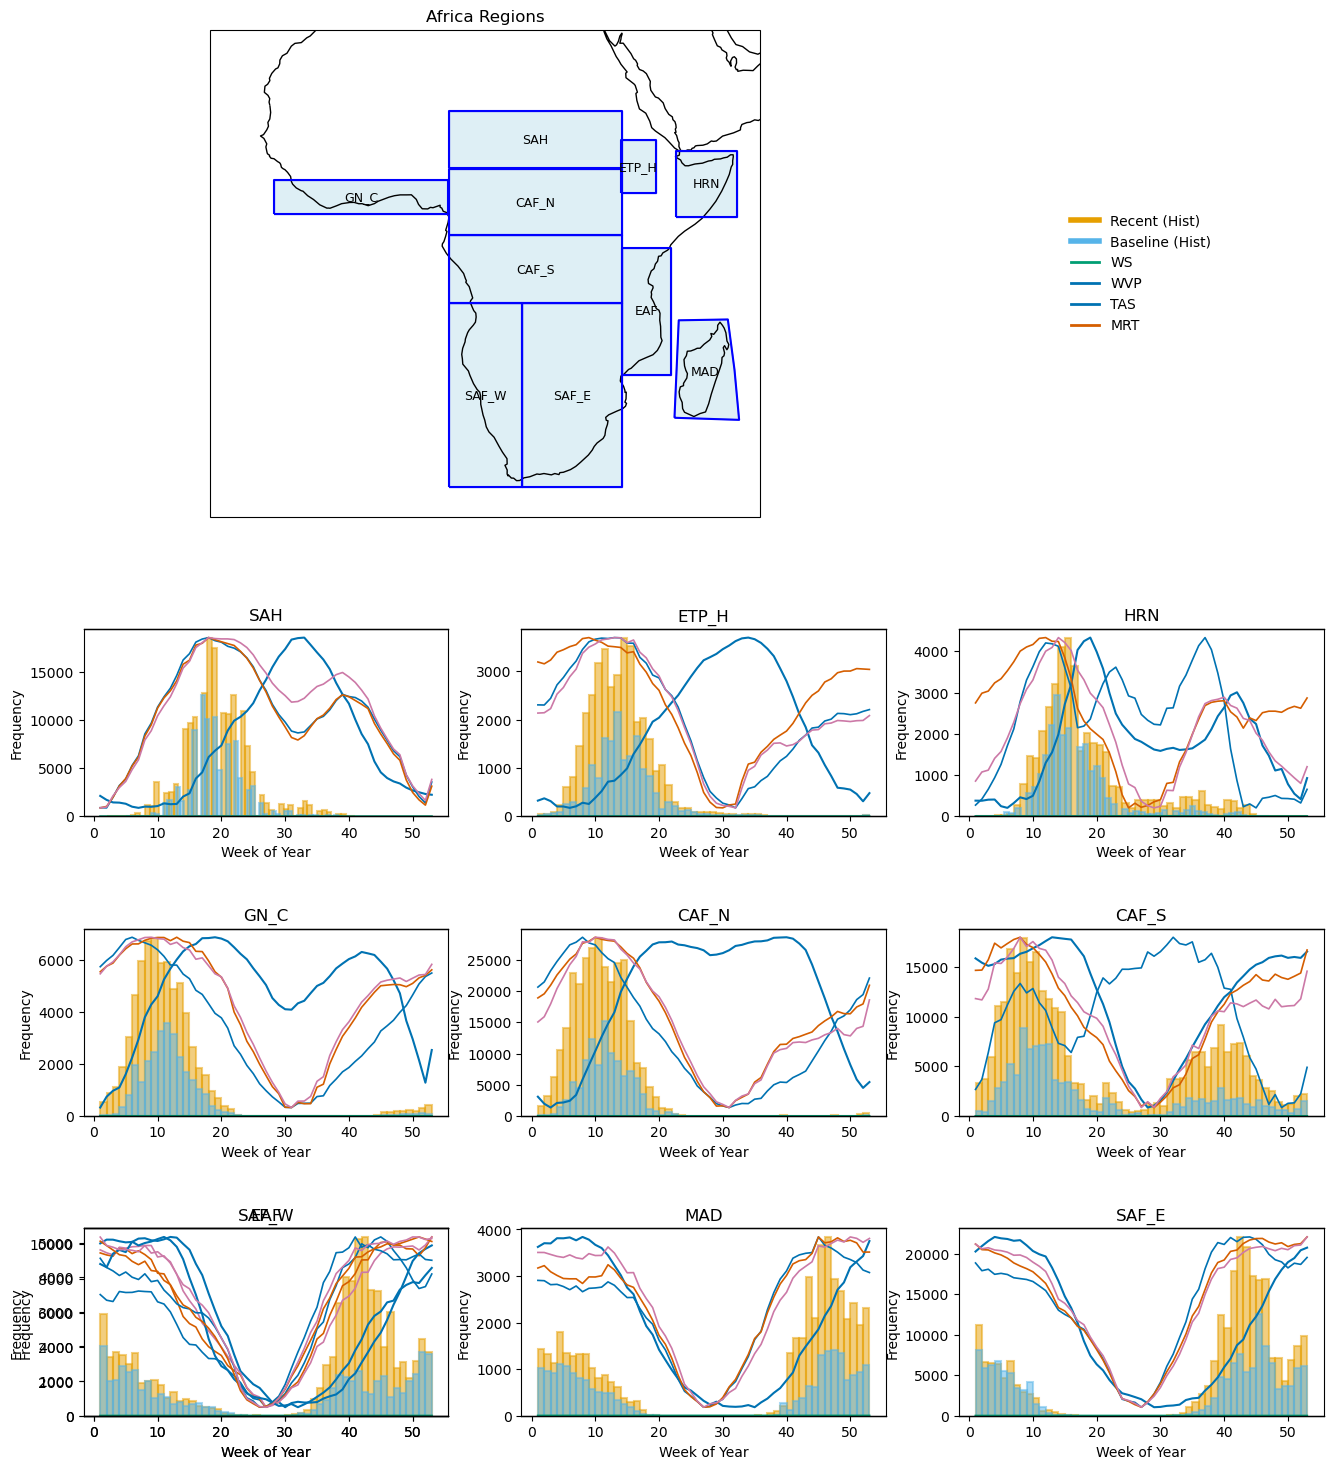

In [117]:
colors = {
    "recent": "#E69F00",  # orange
    "baseline": "#56B4E9",  # blue
    "ws": "#009E73",       # bluish green (not currently used)
    "wvp": "#0072B2",      # updated from yellow to dark blue
    "tas": "#0072B2",      # blue (same as updated wvp)
    "MRT": "#D55E00",      # vermillion
    "UTCI": "#CC79A7",  # purple
}

# List of all regions
region_names = ['SAH', 'ETP_H', 'HRN', 'GN_C', 'CAF_N', 'CAF_S', 'EAF', 'MAD', 'SAF_E', 'SAF_W']

# Create figure and gridspec
fig = plt.figure(figsize=(16, 18))
gs = fig.add_gridspec(5, 3, hspace=0.6)

# Move reference map to top-left and make it span 2 columns
map_ax = fig.add_subplot(gs[0:2, 0:2], projection=ccrs.PlateCarree())
map_ax.set_extent([-25, 55, -40, 30], crs=ccrs.PlateCarree())
map_ax.coastlines()
map_ax.set_title("Africa Regions")

# Plot regions
gdf = gpd.read_file("data/regions.geojson")
gdf.boundary.plot(ax=map_ax, edgecolor='blue')
gdf.plot(ax=map_ax, alpha=0.4, facecolor='lightblue', edgecolor='blue')

# Annotate region labels
for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    label = row.label
    map_ax.text(centroid.x, centroid.y, label, transform=ccrs.PlateCarree(),
                ha='center', va='center', fontsize=9)

# Create histogram subplots
axes = []
for i in range(6):
    ax = fig.add_subplot(gs[2 + i//3, i % 3])
    axes.append(ax)
for i in range(4):
    row = 4
    col = i % 3
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

# Plot histograms
for idx, region in enumerate(region_names):
    ax1 = axes[idx]

    # Load and prep dataset
    ds = regions[region]
    woy = ds.time.dt.isocalendar().week
    woy_broadcasted = xr.ones_like(ds['UTCI']) * woy.values[:, np.newaxis, np.newaxis]
    woy_broadcasted = xr.DataArray(woy_broadcasted, dims=("time", "latitude", "longitude"), coords=ds['UTCI'].coords)
    ds = ds.assign(woy=woy_broadcasted)

    # Filter extreme events
    ds_extreme = ds.where(ds.UTCI > ds.sel(time=baseline_time).UTCI.quantile(0.99, dim='time'))
    ds_extreme = ds_extreme.stack(space=['time', 'latitude', 'longitude'])
    woy_values = ds_extreme.dropna(dim='space').woy

    # Plot histogram with alpha and thicker edge
    ax1.hist(woy_values.sel(time=recent_time).values, bins=52,
             edgecolor=colors["recent"], facecolor=colors["recent"],
             alpha=0.5, linewidth=1.5, label='Recent')
    ax1.hist(woy_values.sel(time=baseline_time).values, bins=52,
             edgecolor=colors["baseline"], facecolor=colors["baseline"],
             alpha=0.5, linewidth=1.5, label='Baseline')

    ax1.set_title(f'{region}')
    ax1.set_xlabel('Week of Year')
    ax1.set_ylabel('Frequency')

    # Area weights
    lat = ds.latitude
    weights = np.cos(np.deg2rad(lat))
    weights /= weights.mean()

    # Climatology
    clim = (
        ds
        .weighted(weights)
        .mean(dim=['latitude', 'longitude'])
        .groupby('time.weekofyear')
        .mean(dim='time')
    )

    # Overlay lines
    ax1.plot(clim.weekofyear, clim.ws, color=colors["ws"], linewidth=1.5)
    ax2 = ax1.twinx()
    ax2.plot(clim.weekofyear, clim.wvp, color=colors["wvp"], linewidth=1.5)
    ax2.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    ax3 = ax1.twinx()
    ax3.spines.right.set_position(("axes", 1.1))
    ax3.plot(clim.weekofyear, clim.tas, color=colors["tas"], linewidth=1.2)
    ax3.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    ax3.spines['left'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    ax4 = ax1.twinx()
    ax4.spines.right.set_position(("axes", 1.2))
    ax4.plot(clim.weekofyear, clim.MRT, color=colors["MRT"], linewidth=1.2)
    ax4.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    ax4.spines['left'].set_visible(False)
    ax4.spines['right'].set_visible(False)

    ax5 = ax1.twinx()
    ax5.spines.right.set_position(("axes", 1.3))
    ax5.plot(clim.weekofyear, clim.UTCI, color=colors["UTCI"], linewidth=1.2)
    ax5.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    ax5.spines['left'].set_visible(False)
    ax5.spines['right'].set_visible(False)

# Combined legend under map
legend_ax = fig.add_subplot(gs[0:2, 2])
legend_ax.axis('off')
legend_handles = [
    plt.Line2D([0], [0], color=colors["recent"], lw=4, label='Recent (Hist)'),
    plt.Line2D([0], [0], color=colors["baseline"], lw=4, label='Baseline (Hist)'),
    plt.Line2D([0], [0], color=colors["ws"], lw=2, label='WS'),
    plt.Line2D([0], [0], color=colors["wvp"], lw=2, label='WVP'),
    plt.Line2D([0], [0], color=colors["tas"], lw=2, label='TAS'),
    plt.Line2D([0], [0], color=colors["MRT"], lw=2, label='MRT'),
    #plt.Line2D([0], [0], color=colors["UTCI"], lw=2, label='UTCI'),
]
legend_ax.legend(handles=legend_handles, loc='center', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/core/dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().we

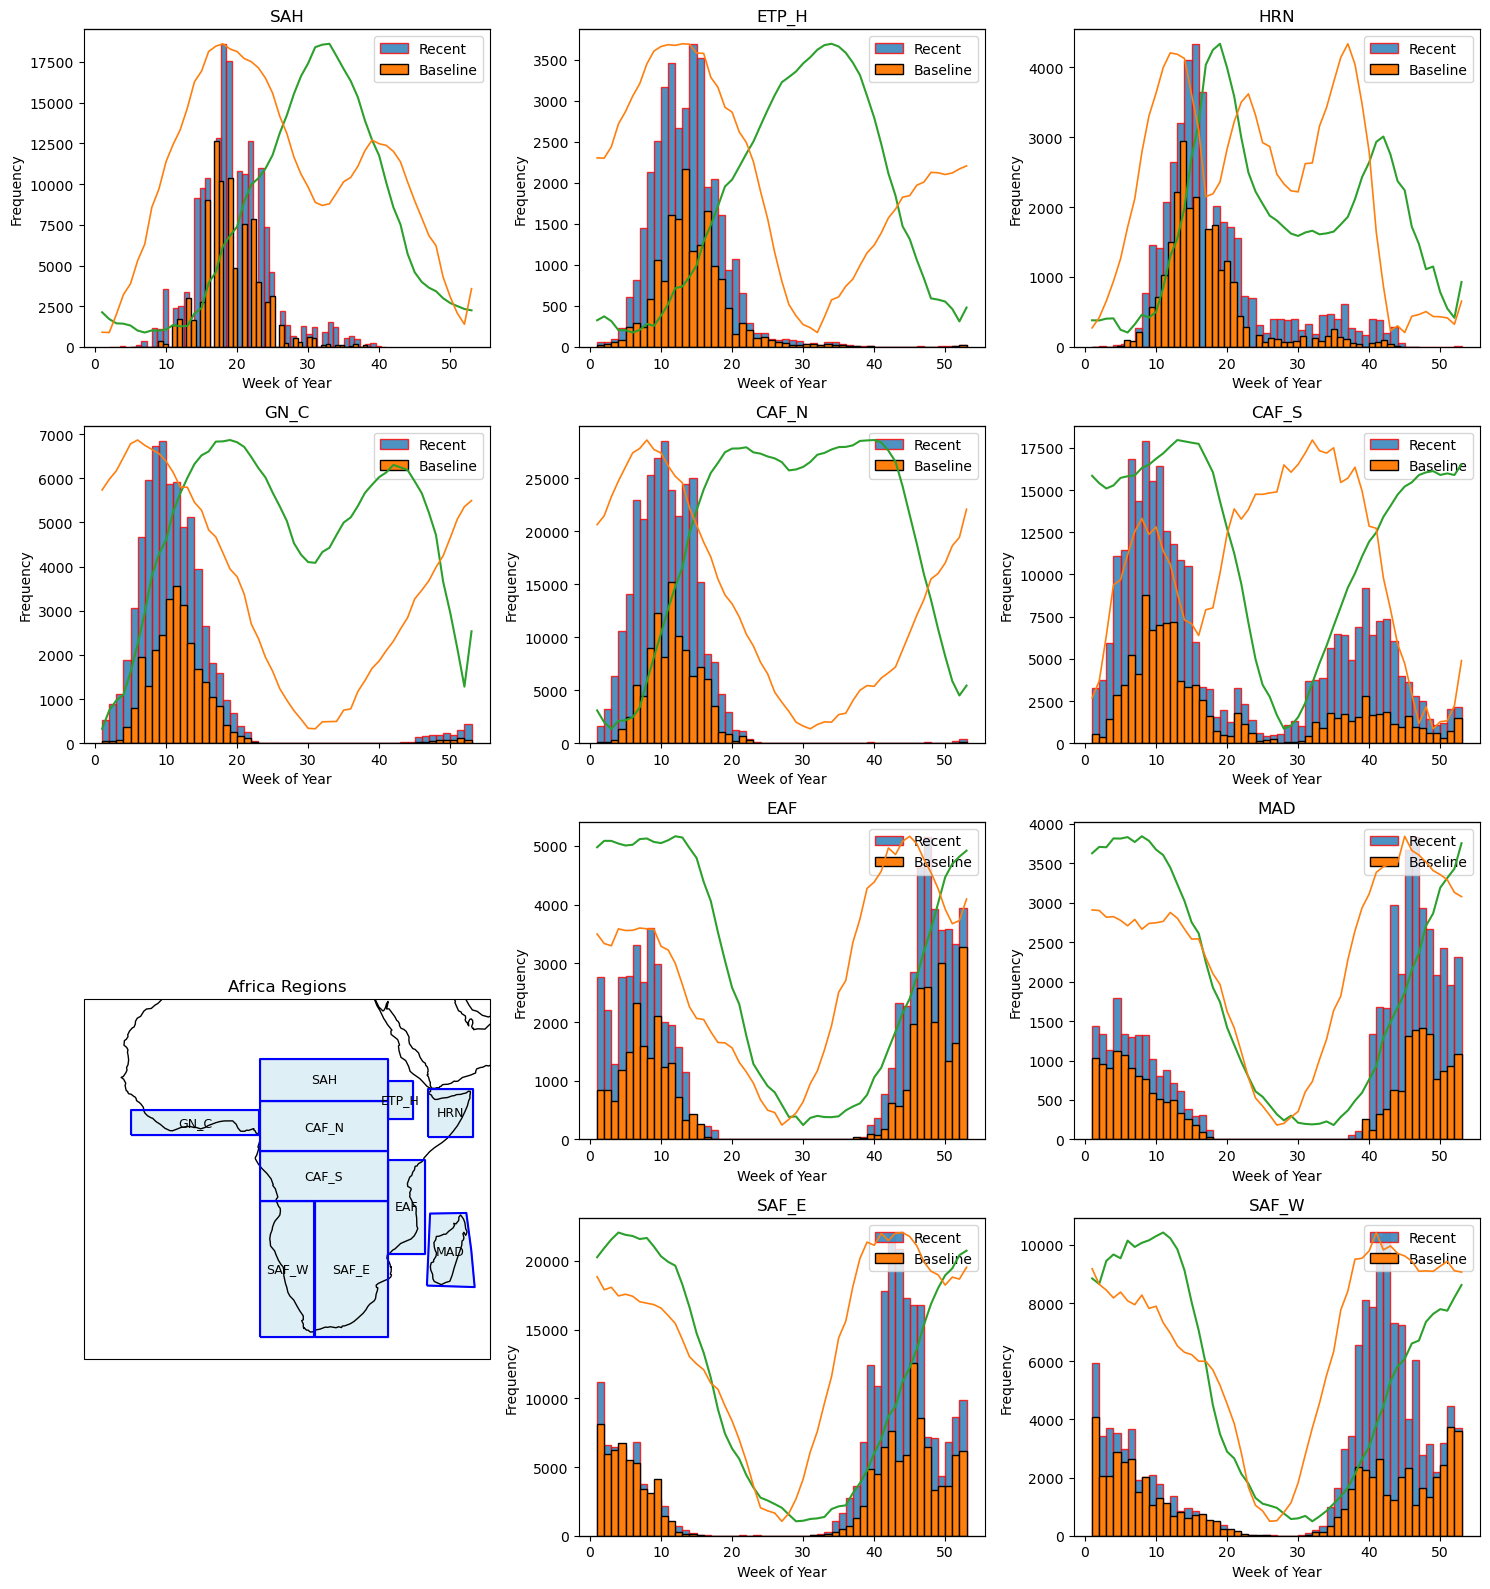

In [121]:
import math
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs

# List of all regions
region_names = ['SAH', 'ETP_H', 'HRN', 'GN_C', 'CAF_N', 'CAF_S', 'EAF', 'MAD', 'SAF_E', 'SAF_W']

# Create figure with a special grid
fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(4, 3)

# Create the map subplot that spans two rows in the first column
map_ax = fig.add_subplot(gs[2:, 0], projection=ccrs.PlateCarree())
map_ax.set_extent([-25, 55, -40, 30], crs=ccrs.PlateCarree())
map_ax.coastlines()
map_ax.set_title("Africa Regions")

# Plot boundaries and fill on map
gdf = gpd.read_file("data/regions.geojson")
gdf.boundary.plot(ax=map_ax, edgecolor='blue')
gdf.plot(ax=map_ax, alpha=0.4, facecolor='lightblue', edgecolor='blue')

# Annotate region labels on map
for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    label = row.label
    map_ax.text(centroid.x, centroid.y, label, transform=ccrs.PlateCarree(),
                ha='center', va='center', fontsize=9)

# Create histogram subplots
axes = []
for i in range(6):
    ax = fig.add_subplot(gs[i//3, i%3])
    axes.append(ax)
for i in range(4):
    row = 2 + i//2
    col = 1 + i%2
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

# Plot histograms + overlay climatology per region
for idx, region in enumerate(region_names):
    ax1 = axes[idx]

    # Load and prep dataset
    ds = regions[region]
    woy = ds.time.dt.isocalendar().week
    woy_broadcasted = xr.ones_like(ds['UTCI']) * woy.values[:, np.newaxis, np.newaxis]
    woy_broadcasted = xr.DataArray(
        woy_broadcasted,
        dims=("time", "latitude", "longitude"),
        coords=ds['UTCI'].coords
    )
    ds = ds.assign(woy=woy_broadcasted)

    # Extreme filtering for histograms
    ds_extreme = ds.where(ds.UTCI > ds.sel(time=baseline_time).UTCI.quantile(0.99, dim='time'))
    ds_extreme = ds_extreme.stack(space=['time', 'latitude', 'longitude'])
    woy_values = ds_extreme.dropna(dim='space').woy

    # Plot histogram
    ax1.hist(woy_values.sel(time=recent_time).values, bins=52,
             edgecolor='red', alpha=0.8, label='Recent')
    ax1.hist(woy_values.sel(time=baseline_time).values, bins=52,
             edgecolor='black', label='Baseline')
    ax1.set_title(f'{region}')
    ax1.set_xlabel('Week of Year')
    ax1.set_ylabel('Frequency')
    ax1.legend(loc='upper right')

    # ---------- Overlay climatology lines ----------
    # Area weights
    lat = ds.latitude
    weights = np.cos(np.deg2rad(lat))
    weights /= weights.mean()

    # Weekly climatology (area-weighted)
    clim = (
        ds
        .weighted(weights)
        .mean(dim=['latitude', 'longitude'])
        .groupby('time.weekofyear')
        .mean(dim='time')
    )

    # 1st overlay: ws (blue)
    #ax1.plot(clim.weekofyear, clim.ws, color='tab:blue', linewidth=1.5)
    #ax1.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    #ax1.spines['left'].set_visible(False)
    #ax1.spines['right'].set_visible(False)

    # 2nd overlay: wvp (green)
    ax2 = ax1.twinx()
    ax2.plot(clim.weekofyear, clim.wvp, color='tab:green', linewidth=1.5)
    ax2.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # 3rd overlay: tas (orange)
    ax3 = ax1.twinx()
    ax3.spines.right.set_position(("axes", 1.1))
    ax3.plot(clim.weekofyear, clim.tas, color='tab:orange', linewidth=1.2)
    ax3.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    ax3.spines['left'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    # 4th overlay: MRT (red)
    #ax4 = ax1.twinx()
    #ax4.spines.right.set_position(("axes", 1.2))
    #ax4.plot(clim.weekofyear, clim.MRT, color='tab:red', linewidth=1.2)
    #ax4.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    #ax4.spines['left'].set_visible(False)
    #ax4.spines['right'].set_visible(False)

    # 5th overlay: UTCI (purple)
    #ax5 = ax1.twinx()
    #ax5.spines.right.set_position(("axes", 1.3))
    #ax5.plot(clim.weekofyear, clim.UTCI, color='tab:purple', linewidth=1.2)
    #ax5.tick_params(axis='y', left=False, labelleft=False, right=False, labelright=False)
    #ax5.spines['left'].set_visible(False)
    #ax5.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

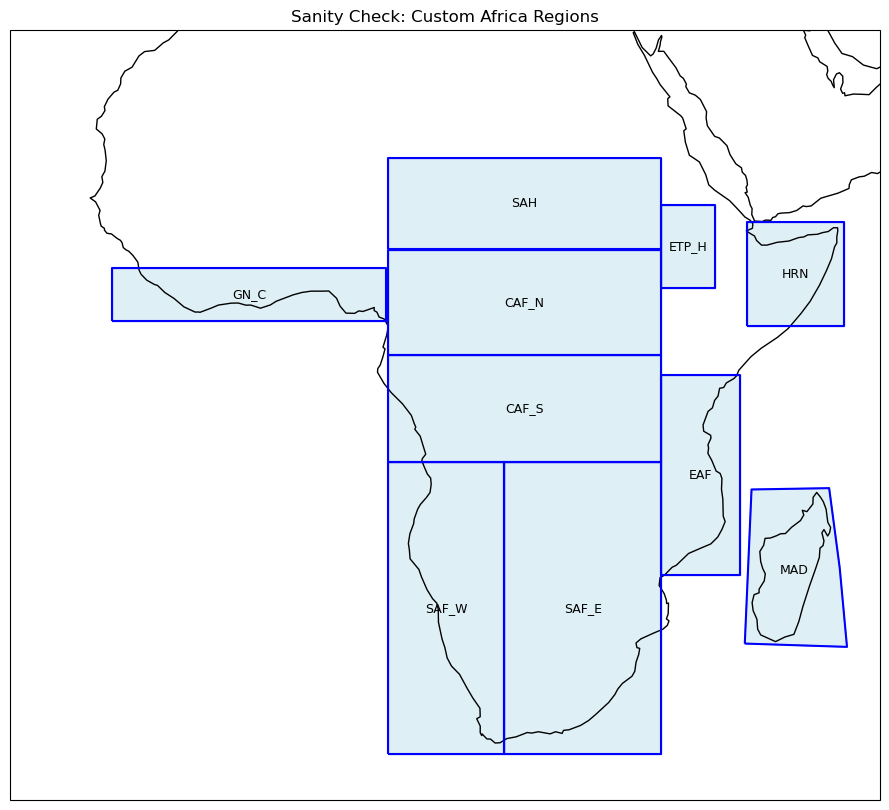

In [109]:
# Load your GeoJSON file (replace with path if saving locally)
gdf = gpd.read_file("data/regions.geojson")

# Plot
fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-25, 55, -40, 30], crs=ccrs.PlateCarree())
ax.coastlines()
ax.set_title("Sanity Check: Custom Africa Regions")

# Plot boundaries and fill
gdf.boundary.plot(ax=ax, edgecolor='blue')
gdf.plot(ax=ax, alpha=0.4, facecolor='lightblue', edgecolor='blue')

# Annotate region labels
for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    label = row.label
    ax.text(centroid.x, centroid.y, label, transform=ccrs.PlateCarree(),
            ha='center', va='center', fontsize=9)

plt.show()
